In [1]:
# General purpose
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Signal processing
from scipy.io import loadmat 
from scipy.ndimage import convolve1d
from scipy.signal import butter
from scipy.signal import sosfiltfilt
from scipy.signal import welch

# Machine learning
from sklearn.model_selection import train_test_split
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.preprocessing import StandardScaler
# Hyperparameter tuning
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import GridSearchCV
# Feature selection
from sklearn.feature_selection import mutual_info_classif
from sklearn.feature_selection import SelectKBest

np.random.seed(42)

In [2]:
FILEPATH_MAT = "data/S2_A1_E1.mat"
FILEPATH_CSV = "data/data.csv"

In [3]:
data = loadmat(FILEPATH_MAT)

print("Dataset variables:")
print([key for key in data.keys() if not key.startswith("__")])

emg = data["emg"]
print("EMG data dimension: {}".format(emg.shape))
print("EMG data type: {}".format(type(emg)))

stimulus = data['restimulus']
repetition = data['rerepetition']

Dataset variables:
['subject', 'exercise', 'stimulus', 'emg', 'glove', 'restimulus', 'repetition', 'rerepetition']
EMG data dimension: (100686, 10)
EMG data type: <class 'numpy.ndarray'>


In [4]:
N_STIMULI = len(np.unique(stimulus)) - 1 # -1 because 0 is the resting condition
N_REPETITIONS = len(np.unique(repetition)) - 1 # -1 because 0 is not a repetition
N_CHANNELS = emg.shape[1]

MOV_MEAN_LENGTH = 100
mov_mean_weights = np.ones(MOV_MEAN_LENGTH) / MOV_MEAN_LENGTH

#initializing the data structure
emg_windows = [[None for repetition_idx in range(N_REPETITIONS)] for stimuli_idx in range(N_STIMULI)] 
emg_envelopes = [[None for repetition_idx in range(N_REPETITIONS)] for stimuli_idx in range(N_STIMULI)]

for stimuli_idx in range(N_STIMULI):
    for repetition_idx in range(N_REPETITIONS):
        idx = np.logical_and(stimulus == stimuli_idx + 1, repetition == repetition_idx + 1).flatten()
        emg_windows[stimuli_idx][repetition_idx] = emg[idx, :]
        emg_envelopes[stimuli_idx][repetition_idx] = convolve1d(emg_windows[stimuli_idx][repetition_idx], mov_mean_weights, axis=0)

## Data Inspection

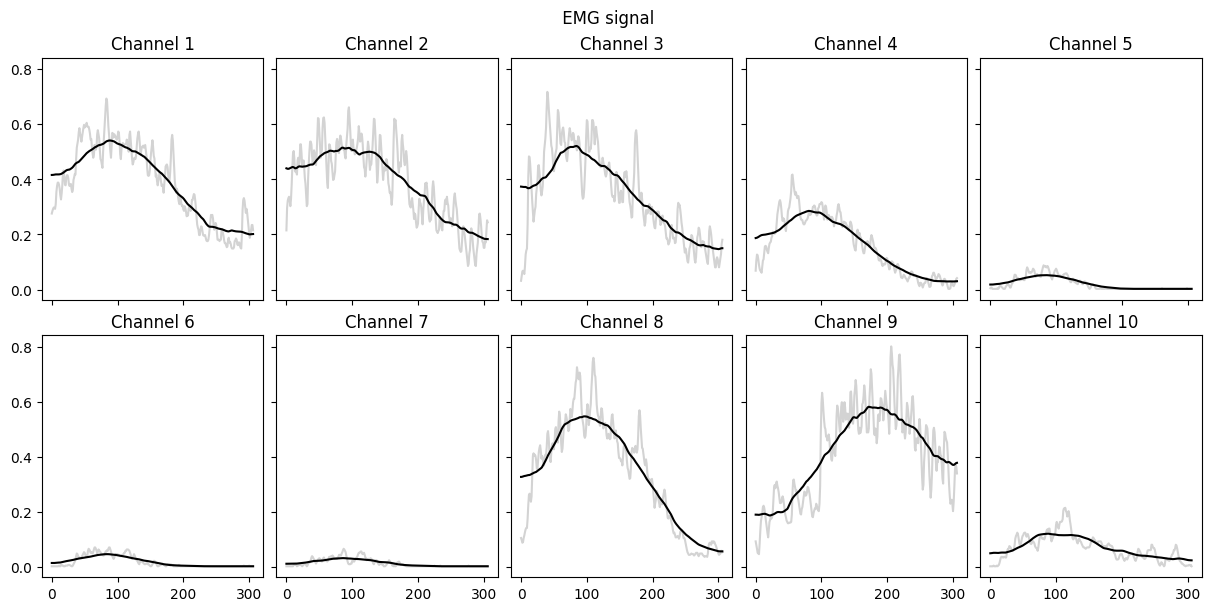

In [5]:
# Now we plot all the channels on the same y-scale
fig, ax = plt.subplots(2, 5, figsize=(12, 6), constrained_layout=True, sharex=True, sharey=True)
ax = ax.ravel()

number_of_emg_channels = emg.shape[-1]

for channel_idx in range(number_of_emg_channels): 
    # plot EMG signal
    ax[channel_idx].plot(emg_windows[0][0][:, channel_idx], color='lightgray')
    ax[channel_idx].set_title(f"Channel {channel_idx+1}")

    # Plot Enveloped signal
    ax[channel_idx].plot(emg_envelopes[0][0][:, channel_idx], color='black')
    ax[channel_idx].set_title(f"Channel {channel_idx+1}")
plt.suptitle(" EMG signal")
plt.show()

Number of channels: 10, Number of stimuli: 12, Number of repetitions: 10


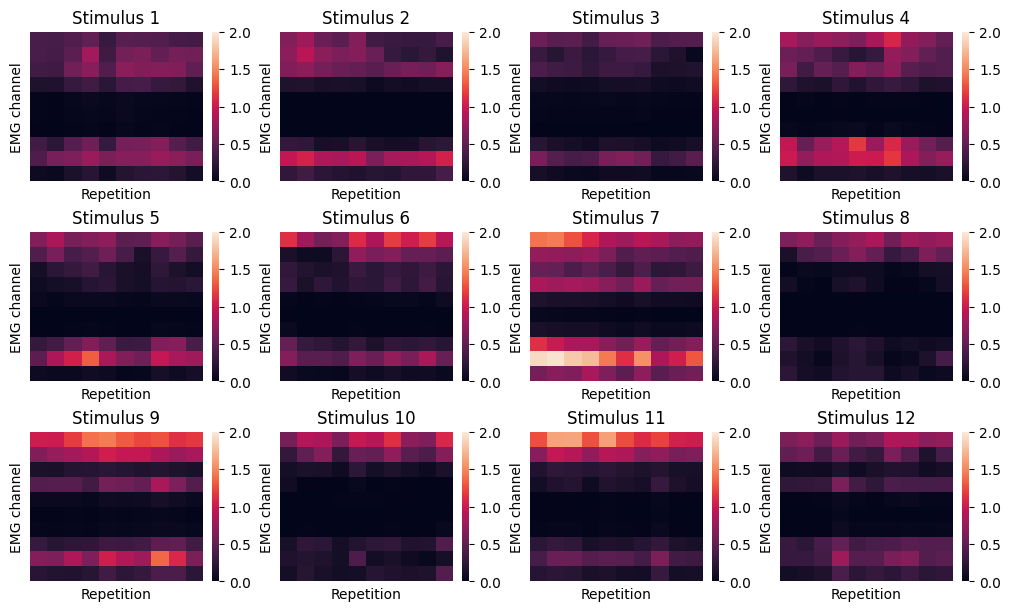

In [6]:
print(f"Number of channels: {N_CHANNELS}, Number of stimuli: {N_STIMULI}, Number of repetitions: {N_REPETITIONS}")
emg_average_activations = np.zeros((N_CHANNELS, N_STIMULI, N_REPETITIONS))
for stimuli_idx in range(N_STIMULI):
    for repetition_idx in range(N_REPETITIONS):
        #mean across time for each channel
        emg_average_activations[:, stimuli_idx, repetition_idx] = np.mean(emg_envelopes[stimuli_idx][repetition_idx], axis=0) 

fig, ax = plt.subplots(3, 4, figsize=(10, 6), constrained_layout=True, sharex=True, sharey=True)
ax = ax.ravel()

for stimuli_idx in range(N_STIMULI):
    sns.heatmap(np.squeeze(emg_average_activations[:, stimuli_idx, :]), 
                ax=ax[stimuli_idx],
                vmin=0, 
                vmax=2.0,
                xticklabels=False, 
                yticklabels=False, 
                cbar = True)
    ax[stimuli_idx].title.set_text("Stimulus " + str(stimuli_idx + 1))
    ax[stimuli_idx].set_xlabel("Repetition")
    ax[stimuli_idx].set_ylabel("EMG channel")

In [7]:
def build_dataset_from_ninapro(emg, stimulus, repetition, features=[]):
    # Calculate the number of unique stimuli and repetitions, subtracting 1 to exclude the resting condition
    n_stimuli = np.unique(stimulus).size - 1
    n_repetitions = np.unique(repetition).size - 1
    # Total number of samples is the product of stimuli and repetitions
    n_samples = n_stimuli * n_repetitions
    
    # Number of channels in the EMG data
    n_channels = emg.shape[1]
    # Calculate the total number of features by summing the number of channels for each feature
    n_features = sum(n_channels for feature in features)
    
    # Initialize the dataset and labels arrays with zeros
    dataset = np.zeros((n_samples, n_features))
    labels = np.zeros(n_samples)
    current_sample_index = 0
    
    # Loop over each stimulus and repetition to extract features
    for i in range(n_stimuli):
        for j in range(n_repetitions):
            # Assign the label for the current sample
            labels[current_sample_index] = i + 1
            # Calculate the current sample index based on stimulus and repetition
            current_sample_index = i * n_repetitions + j
            current_feature_index = 0
            # Select the time steps corresponding to the current stimulus and repetition
            selected_tsteps = np.logical_and(stimulus == i + 1, repetition == j + 1).squeeze()
            
            # Loop over each feature function provided
            for feature in features:
                # Determine the indices in the dataset where the current feature will be stored
                selected_features = np.arange(current_feature_index, current_feature_index + n_channels)
                # Apply the feature function to the selected EMG data and store the result
                dataset[current_sample_index, selected_features] = feature(emg[selected_tsteps, :])
                # Update the feature index for the next feature
                current_feature_index += n_channels

            # Move to the next sample
            current_sample_index += 1
            
    # Return the constructed dataset and corresponding labels
    return dataset, labels

In [20]:

# Mean absolute value (MAV)
mav = lambda x: np.mean(np.abs(x), axis=0)
# Standard Deviation (STD)
std = lambda x: np.std(x, axis=0)
# Maximum absolute Value (MaxAV)
maxav = lambda x: np.max(np.abs(x), axis=0)
# Root mean square (RMS)
rms = lambda x: np.sqrt(np.mean(x**2, axis=0))
# Waveform length (WL)
wl = lambda x: np.sum(np.abs(np.diff(x, axis=0)), axis=0)
# Slope sign changes (SSC)
ssc = lambda x: np.sum((np.diff(x, axis=0)[:-1, :] * np.diff(x, axis=0)[1:, :]) < 0, axis=0)

# Additional features from the paper:
# Zero Crossings (ZC) with threshold to reduce noise sensitivity
def zc(x, th=0.01):
    # x: (T, C)
    dx = x[:-1, :] * x[1:, :]
    crossings = (dx < 0) & (np.abs(x[:-1, :]) > th) | (np.abs(x[1:, :]) > th)
    return np.sum(crossings, axis=0).astype(float)

# Willison Amplitude (WAMP) - counts of large amplitude differences
def wamp(x, th=0.02):
    return np.sum(np.abs(np.diff(x, axis=0)) > th, axis=0).astype(float)

# Simple FD features: mean frequency and median frequency per channel
def mean_freq(x, fs=2000):
    f, Pxx = welch(x, fs=fs, axis=0, nperseg=min(256, max(8, x.shape[0])))
    Psum = np.sum(Pxx, axis=0) + 1e-12
    return np.sum(f[:, None] * Pxx, axis=0) / Psum

def median_freq(x, fs=2000):
    f, Pxx = welch(x, fs=fs, axis=0, nperseg=min(256, max(8, x.shape[0])))
    Pcum = np.cumsum(Pxx, axis=0)
    total = Pcum[-1, :] + 1e-12
    med = np.zeros(x.shape[1])
    for c in range(x.shape[1]):
        idx = np.searchsorted(Pcum[:, c], total[c] / 2.0)
        med[c] = f[min(idx, f.size - 1)]
    return med

# Combine all features into a dict (keys are used later for selecting subsets)
all_features = {
    "mav": mav,
    "std": std,
    "maxav": maxav,
    "rms": rms,
    "wl": wl,
    "ssc": ssc,
    "zc": zc,
    "wamp": wamp,
    "mean_freq": mean_freq,
    "median_freq": median_freq,
}

#TODO: Feel free to add more features, e.g. frequency domain features. (See https://doi.org/10.3390/s19204596 and https://doi.org/10.1088/0967-3334/24/2/307)

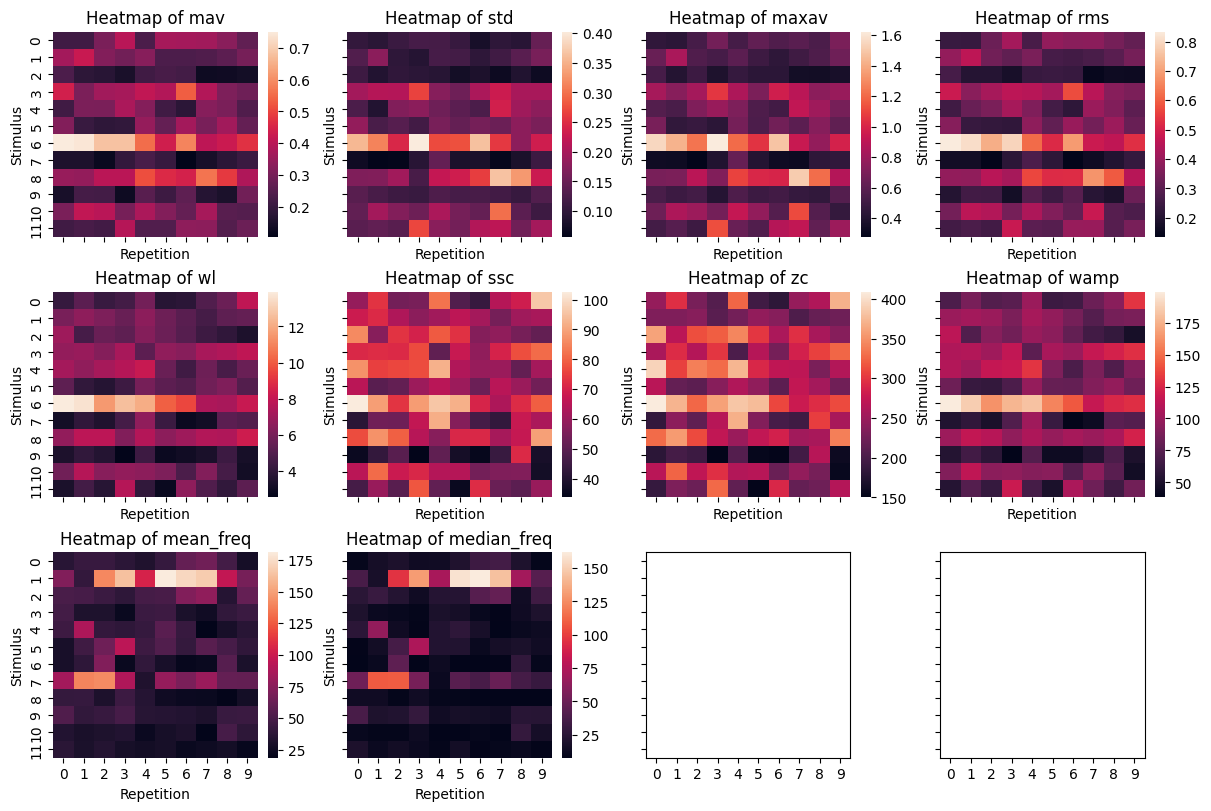

In [22]:
# Visualise all feature accross all trials as a heatmap

fig, ax = plt.subplots(3, 4, figsize=(12, 8), constrained_layout=True, sharex=True, sharey=True)
ax = ax.ravel()

for ax_idx, (feature_name, feature_func) in enumerate(all_features.items()):
    feature_values = []
    for stimuli_idx in range(N_STIMULI):
        for repetition_idx in range(N_REPETITIONS):
            mask = np.logical_and(stimulus == stimuli_idx + 1, repetition == repetition_idx + 1).flatten()
            feature_value = feature_func(emg[mask, :])
            feature_values.append(np.mean(feature_value))  # Mean across channels

    sns.heatmap(np.array(feature_values).reshape(N_STIMULI, N_REPETITIONS), annot=False, fmt=".2f", ax=ax[ax_idx])
    ax[ax_idx].set_title(f"Heatmap of {feature_name}")
    ax[ax_idx].set_xlabel("Repetition")
    ax[ax_idx].set_ylabel("Stimulus")
plt.show()

In [10]:
dataset, labels = build_dataset_from_ninapro(
        emg=emg,
        stimulus=stimulus,
        repetition=repetition,
        features=all_features.values()
)

# Split the dataset into training and testing sets
# Here, 30% of the data is reserved for testing, and 70% is used for training
X_train, X_test, y_train, y_test = train_test_split(dataset, labels, test_size=0.3)

# Normalizing the data
# StandardScaler is used to scale the features so that they have a mean of 0 and a standard deviation of 1
scaler = StandardScaler()
X_train_z = scaler.fit_transform(X_train)  # Fit the scaler on the training data and transform it
X_test_z = scaler.transform(X_test)        # Transform the test data using the same scaler

# We are using a Gradient Boosting classifier from sklearn
clf = GradientBoostingClassifier(random_state=42)
clf.fit(X_train_z, y_train)  # Fit the model on the training data

# Evaluate the classifier on the test set
# Predict the labels for the test set
y_pred = clf.predict(X_test_z)
# Calculate the accuracy of the model
accuracy = accuracy_score(y_test, y_pred)
print(f"Simple Gradient Boosting accuracy score: {accuracy}")

# perform cross-validation
CV = 5
scores = cross_val_score(clf, X_train_z, y_train, cv=CV)
print(f"Accuracy scores of all {CV} models: {scores}")
print(f"Mean accuracy across all {CV} models: {np.mean(scores)}")

Simple Gradient Boosting accuracy score: 0.8333333333333334
Accuracy scores of all 5 models: [0.82352941 0.64705882 0.70588235 0.58823529 0.8125    ]
Mean accuracy across all 5 models: 0.7154411764705884
Accuracy scores of all 5 models: [0.82352941 0.64705882 0.70588235 0.58823529 0.8125    ]
Mean accuracy across all 5 models: 0.7154411764705884


In [11]:
from itertools import combinations

feature_names = list(all_features.keys())

# Generate all non-empty feature subsets
all_feature_sets = []
for r in range(1, len(feature_names) + 1):
    for combo in combinations(feature_names, r):
        all_feature_sets.append(combo)

print(f"Total number of feature subsets: {len(all_feature_sets)}")
print([set for set in all_feature_sets])

one_feature_set = [all_feature_sets[-1]]
print(f"Total number of feature subsets: {len(one_feature_set)}")
print([set for set in one_feature_set])

Total number of feature subsets: 15
[('mav',), ('std',), ('maxav',), ('rms',), ('mav', 'std'), ('mav', 'maxav'), ('mav', 'rms'), ('std', 'maxav'), ('std', 'rms'), ('maxav', 'rms'), ('mav', 'std', 'maxav'), ('mav', 'std', 'rms'), ('mav', 'maxav', 'rms'), ('std', 'maxav', 'rms'), ('mav', 'std', 'maxav', 'rms')]
Total number of feature subsets: 1
[('mav', 'std', 'maxav', 'rms')]


## Classification

In [12]:
param_grid = {
    "n_estimators": [50, 100, 200],
    "learning_rate": [0.01, 0.1, 0.2],
    "max_depth": [1, 3, 5],
    "subsample": [0.8, 1.0]
}

CV = 3
TEST_SIZE = 0.3

# store results for later analysis / visualisation
results = []

n_iterations = len(all_feature_sets)

for i, subset in enumerate(all_feature_sets):
    print(f"Evaluating subset {i+1}/{n_iterations}: {subset}"+ " " * 50, end="\r")

    # build dataset for this feature subset
    dataset, labels = build_dataset_from_ninapro(
        emg=emg,
        stimulus=stimulus,
        repetition=repetition,
        features=[all_features[name] for name in subset],
    )

    X_train, X_test, y_train, y_test = train_test_split(dataset, labels, test_size=TEST_SIZE)
    scaler = StandardScaler()
    X_train_z = scaler.fit_transform(X_train)
    X_test_z = scaler.transform(X_test)

    grid = GridSearchCV(GradientBoostingClassifier(random_state=42), param_grid, cv=CV, n_jobs=-1)
    grid.fit(X_train_z, y_train)

    y_pred = grid.predict(X_test_z)
    acc = accuracy_score(y_test, y_pred)
    cm = confusion_matrix(y_test, y_pred)

    results.append({
        "feature_set": "+".join(subset),
        "subset_tuple": subset,
        "n_features": dataset.shape[1],
        "best_params": grid.best_params_,
        "best_cv_score": grid.best_score_,
        "test_accuracy": acc,
        "confusion_matrix": cm,
        "cv_results": grid.cv_results_,
        "y_test": y_test,
        "y_pred": y_pred
    })



In [13]:
results_df = pd.DataFrame([{
    "feature_set": r["feature_set"],
    "n_features": r["n_features"],
    "best_params": r["best_params"],
    "best_cv_score": r["best_cv_score"],
    "test_accuracy": r["test_accuracy"],
    "confusion_matrix": r["confusion_matrix"].tolist(),
    "y_test": r["y_test"].tolist(),
    "y_pred": r["y_pred"].tolist()
} for r in results])

# create a summary DataFrame (excluding large objects)
summary = pd.DataFrame([{
    "feature_set": r["feature_set"],
    "n_features": r["n_features"],
    "best_params": r["best_params"],
    "best_cv_score": r["best_cv_score"],
    "test_accuracy": r["test_accuracy"]
} for r in results])

# save results to disk for later inspection

results_df.to_csv("results/gb_feature_search_results.csv", index=False)
summary.to_csv("results/gb_feature_search_summary.csv", index=False)

# show top results
print("Top 10 subsets by test accuracy:")
print(summary.sort_values("test_accuracy", ascending=False).head(10))

Top 10 subsets by test accuracy:
      feature_set  n_features  \
5       mav+maxav          20   
1             std          10   
2           maxav          10   
3             rms          10   
4         mav+std          20   
6         mav+rms          20   
10  mav+std+maxav          30   
11    mav+std+rms          30   
12  mav+maxav+rms          30   
7       std+maxav          20   

                                          best_params  best_cv_score  \
5   {'learning_rate': 0.2, 'max_depth': 1, 'n_esti...       0.690476   
1   {'learning_rate': 0.2, 'max_depth': 3, 'n_esti...       0.773810   
2   {'learning_rate': 0.1, 'max_depth': 1, 'n_esti...       0.654762   
3   {'learning_rate': 0.2, 'max_depth': 1, 'n_esti...       0.809524   
4   {'learning_rate': 0.1, 'max_depth': 1, 'n_esti...       0.690476   
6   {'learning_rate': 0.2, 'max_depth': 5, 'n_esti...       0.773810   
10  {'learning_rate': 0.2, 'max_depth': 1, 'n_esti...       0.833333   
11  {'learning_rate': 0.1, 

### Visualisation

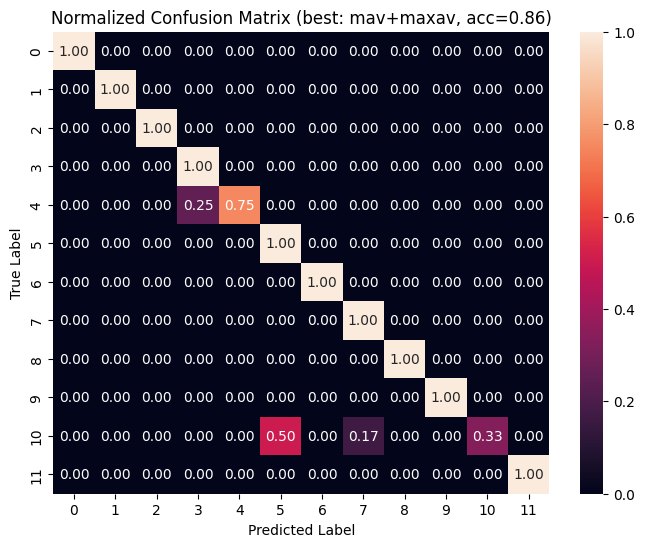

In [16]:
# Load best result and visualise normalized confusion matrix (rows sum to 1)
best_result = max(results, key=lambda r: r["test_accuracy"])
cm = np.array(best_result["confusion_matrix"], dtype=float)

# normalize by true label (rows) so each row sums to 1
row_sums = cm.sum(axis=1, keepdims=True)
cm_norm = np.divide(cm, row_sums, out=np.zeros_like(cm), where=row_sums!=0)

plt.figure(figsize=(8, 6))
sns.heatmap(cm_norm, annot=True, fmt=".2f", cbar=True)
plt.title(f'Normalized Confusion Matrix (best: {best_result["feature_set"]}, acc={best_result["test_accuracy"]:.2f})')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()


## Feature selection

Mutual information per feature (descending):
|       feature        mi
0          mav  0.770386
1          rms  0.767041
2          std  0.722802
3           wl  0.721154
4        maxav  0.699297
5         wamp  0.519083
6           zc  0.421891
7          ssc  0.353887
8    mean_freq  0.335120
9  median_freq  0.248656

Top 3 features: ['mav', 'rms', 'std']


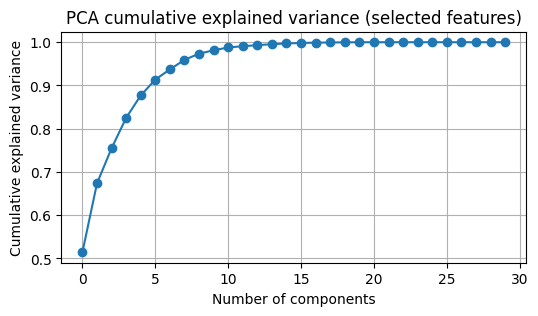

5-fold CV accuracy on PCA-reduced selected features: [0.45833333 0.83333333 0.70833333 0.83333333 0.70833333], mean=0.708


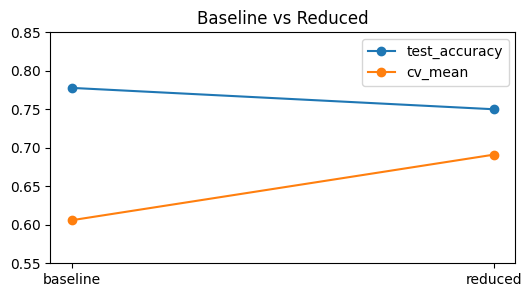

In [33]:
# Perform Feature Selection and Dimensionality Reduction
# 1) Rank feature *functions* (MAV, STD, ...) by mutual information (avg across channels),
# 2) Select top-K feature functions, 3) build reduced dataset,
# 4) apply PCA, plot cumulative explained variance and pick components >=90% variance,
# 5) run a quick 5-fold CV sanity check and save MI ranking.

# Rebuild dataset using all features to compute mutual information scores
dataset_all, labels_all = build_dataset_from_ninapro(emg, stimulus, repetition, features=all_features.values())

# Compute mutual information per column (each column = one channel of one feature)
mi = mutual_info_classif(dataset_all, labels_all, discrete_features=False, random_state=42)

# Aggregate MI by feature function (each feature contributes N_CHANNELS columns)
feature_names = list(all_features.keys())
mi_per_feature = [mi[i*N_CHANNELS:(i+1)*N_CHANNELS].mean() for i in range(len(feature_names))]

mi_df = pd.DataFrame({"feature": feature_names, "mi": mi_per_feature})
mi_df = mi_df.sort_values("mi", ascending=False).reset_index(drop=True)
print(f"Mutual information per feature (descending):\n|{mi_df}")

# Select top-K feature functions (adjust TOP_K as needed)
TOP_K = 3
top_features = mi_df['feature'].values[:TOP_K].tolist()
print(f"\nTop {TOP_K} features: {top_features}")

# Build reduced dataset containing only the selected feature functions
selected_feature_funcs = [all_features[f] for f in top_features]
X_sel, y_sel = build_dataset_from_ninapro(emg, stimulus, repetition, features=selected_feature_funcs)

# Standardize and apply PCA
from sklearn.decomposition import PCA
scaler_sel = StandardScaler()
X_sel_z = scaler_sel.fit_transform(X_sel)

# Fit PCA (limit max components to a reasonable number for plotting)
pca = PCA(n_components=None, random_state=42)
X_pca = pca.fit_transform(X_sel_z)

# Plot cumulative explained variance to pick number of components
import matplotlib.pyplot as plt
plt.figure(figsize=(6, 3))
plt.plot(np.cumsum(pca.explained_variance_ratio_), marker='o')
plt.xlabel('Number of components')
plt.ylabel('Cumulative explained variance')
plt.title('PCA cumulative explained variance (selected features)')
plt.grid(True)
plt.show()

# Choose number of components that capture >=90% variance (or fall back to max_components)
cumvar = np.cumsum(pca.explained_variance_ratio_)
n_components_90 = int(np.searchsorted(cumvar, 0.9) + 1) if cumvar.size>0 else 1
n_components = min(n_components_90, X_pca.shape[1])

# Final reduced representation
X_pca_reduced = X_pca[:, :n_components]

# Quick classifier sanity check (5-fold CV) on reduced data
clf_quick = GradientBoostingClassifier(random_state=42)
scores = cross_val_score(clf_quick, X_pca_reduced, y_sel, cv=5)
print(f"5-fold CV accuracy on PCA-reduced selected features: {scores}, mean={np.mean(scores):.3f}")

# Expose variables for downstream cells
selected_feature_names = top_features
pca_model = pca
X_reduced = X_pca_reduced
y_reduced = y_sel

# ------------------------------------------------------------------
# Evaluate performance vs. baseline (same metric as earlier: test accuracy + 5-fold CV on training)
# ------------------------------------------------------------------

# Rebuild full dataset using all features for a fair baseline
X_all, y_all = build_dataset_from_ninapro(emg, stimulus, repetition, features=all_features.values())
# Hold-out split matching previous cells (30% test)
X_train_all, X_test_all, y_train_all, y_test_all = train_test_split(X_all, y_all, test_size=0.3, random_state=42)
scaler_all = StandardScaler()
X_train_all_z = scaler_all.fit_transform(X_train_all)
X_test_all_z = scaler_all.transform(X_test_all)
# Train and evaluate baseline classifier
clf_base = GradientBoostingClassifier(random_state=42)
clf_base.fit(X_train_all_z, y_train_all)
y_pred_all = clf_base.predict(X_test_all_z)
baseline_test_acc = accuracy_score(y_test_all, y_pred_all)
baseline_cv_scores = cross_val_score(clf_base, X_train_all_z, y_train_all, cv=5)
baseline_cv_mean = np.mean(baseline_cv_scores)


# Evaluate reduced PCA representation using the same procedure
# Use the PCA-reduced data computed above: X_reduced, y_reduced
X_train_red, X_test_red, y_train_red, y_test_red = train_test_split(X_reduced, y_reduced, test_size=0.3, random_state=42)
scaler_red = StandardScaler()
X_train_red_z = scaler_red.fit_transform(X_train_red)
X_test_red_z = scaler_red.transform(X_test_red)
clf_red = GradientBoostingClassifier(random_state=42)
clf_red.fit(X_train_red_z, y_train_red)
y_pred_red = clf_red.predict(X_test_red_z)
red_test_acc = accuracy_score(y_test_red, y_pred_red)
red_cv_scores = cross_val_score(clf_red, X_train_red_z, y_train_red, cv=5)
red_cv_mean = np.mean(red_cv_scores)

# Compare and report
improved_test = red_test_acc > baseline_test_acc
improved_cv = red_cv_mean > baseline_cv_mean

# Prepare comparison DataFrame
comp_df = pd.DataFrame([{'metric': 'test_accuracy', 'baseline': baseline_test_acc, 'reduced': red_test_acc},
                        {'metric': 'cv_mean', 'baseline': baseline_cv_mean, 'reduced': red_cv_mean}])
# Round numeric columns for nicer display
comp_df[['baseline', 'reduced']] = comp_df[['baseline', 'reduced']].astype(float).round(3)

# Plot test_accuracy and cv_mean as two lines across ['baseline','reduced']
labels = ['baseline', 'reduced']

test_vals = [baseline_test_acc, red_test_acc]
cv_vals = [baseline_cv_mean, red_cv_mean]

plt.figure(figsize=(6,3))
plt.plot(labels, test_vals, marker='o', label='test_accuracy')
plt.plot(labels, cv_vals, marker='o', label='cv_mean')
plt.ylim(0.55,0.85)
plt.title('Baseline vs Reduced')
plt.legend()
plt.show()

Mutual information per feature (descending):
       feature        mi
0          mav  0.770386
1          rms  0.767041
2          std  0.722802
3           wl  0.721154
4        maxav  0.699297
5         wamp  0.519083
6           zc  0.421891
7          ssc  0.353887
8    mean_freq  0.335120
9  median_freq  0.248656

Top 3 features: ['mav', 'rms', 'std']


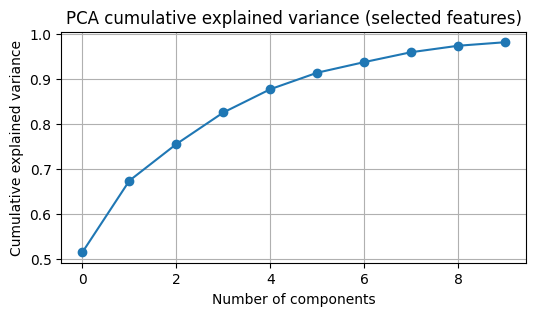

5-fold CV accuracy on PCA-reduced selected features: [0.45833333 0.83333333 0.70833333 0.83333333 0.70833333], mean=0.708

Comparison:
          metric  baseline  reduced
0  test_accuracy     0.778    0.750
1        cv_mean     0.606    0.691

Comparison:
          metric  baseline  reduced
0  test_accuracy     0.778    0.750
1        cv_mean     0.606    0.691


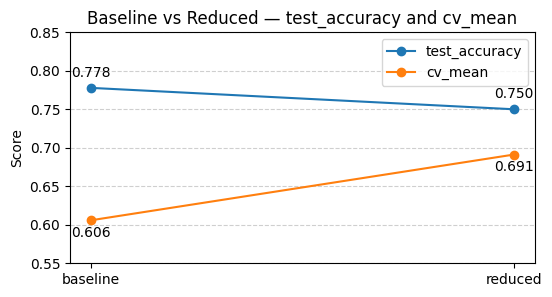

In [39]:
# Combined Feature Selection and Dimensionality Reduction Pipeline

# 1. Compute mutual information for all feature functions
# 2. Select top-K feature functions
# 3. Build reduced dataset
# 4. Apply PCA and compute components covering >=90% variance
# 5. Quick 5-fold CV sanity check
# 6. Baseline vs Reduced performance comparison

# --- Feature Selection with Mutual Information ---

dataset_all, labels_all = build_dataset_from_ninapro(
    emg, stimulus, repetition, features=all_features.values()
)

mi = mutual_info_classif(dataset_all, labels_all, discrete_features=False, random_state=42)

feature_names = list(all_features.keys())
mi_per_feature = [mi[i*N_CHANNELS:(i+1)*N_CHANNELS].mean() for i in range(len(feature_names))]

mi_df = pd.DataFrame({"feature": feature_names, "mi": mi_per_feature})
mi_df = mi_df.sort_values("mi", ascending=False).reset_index(drop=True)
print("Mutual information per feature (descending):")
print(mi_df)

TOP_K = 3
top_features = mi_df['feature'].values[:TOP_K].tolist()
print(f"\nTop {TOP_K} features: {top_features}")

# --- Build Reduced Dataset ---
selected_feature_funcs = [all_features[f] for f in top_features]
X_sel, y_sel = build_dataset_from_ninapro(
    emg, stimulus, repetition, features=selected_feature_funcs
)

# --- PCA on Selected Features ---
scaler_sel = StandardScaler()
X_sel_z = scaler_sel.fit_transform(X_sel)

from sklearn.decomposition import PCA
max_components = min(10, X_sel_z.shape[1])
pca = PCA(n_components=max_components, random_state=42)
X_pca = pca.fit_transform(X_sel_z)

plt.figure(figsize=(6, 3))
plt.plot(np.cumsum(pca.explained_variance_ratio_), marker='o')
plt.xlabel('Number of components')
plt.ylabel('Cumulative explained variance')
plt.title('PCA cumulative explained variance (selected features)')
plt.grid(True)
plt.show()

cumvar = np.cumsum(pca.explained_variance_ratio_)
n_components_90 = int(np.searchsorted(cumvar, 0.9) + 1) if cumvar.size > 0 else 1
n_components = min(n_components_90, X_pca.shape[1])

X_pca_reduced = X_pca[:, :n_components]

# --- 5-fold CV sanity check ---
clf_quick = GradientBoostingClassifier(random_state=42)
scores = cross_val_score(clf_quick, X_pca_reduced, y_sel, cv=5)
print(f"5-fold CV accuracy on PCA-reduced selected features: {scores}, mean={np.mean(scores):.3f}")

# Expose for downstream
selected_feature_names = top_features
pca_model = pca
X_reduced = X_pca_reduced
y_reduced = y_sel

# --- Baseline vs Reduced Comparison ---
X_all, y_all = build_dataset_from_ninapro(
    emg, stimulus, repetition, features=all_features.values()
)

X_train_all, X_test_all, y_train_all, y_test_all = train_test_split(
    X_all, y_all, test_size=0.3, random_state=42
)
scaler_all = StandardScaler()
X_train_all_z = scaler_all.fit_transform(X_train_all)
X_test_all_z = scaler_all.transform(X_test_all)

clf_base = GradientBoostingClassifier(random_state=42)
clf_base.fit(X_train_all_z, y_train_all)
y_pred_all = clf_base.predict(X_test_all_z)
baseline_test_acc = accuracy_score(y_test_all, y_pred_all)
baseline_cv_scores = cross_val_score(clf_base, X_train_all_z, y_train_all, cv=5)
baseline_cv_mean = np.mean(baseline_cv_scores)

# Reduced pipeline
X_train_red, X_test_red, y_train_red, y_test_red = train_test_split(
    X_reduced, y_reduced, test_size=0.3, random_state=42
)
scaler_red = StandardScaler()
X_train_red_z = scaler_red.fit_transform(X_train_red)
X_test_red_z = scaler_red.transform(X_test_red)

clf_red = GradientBoostingClassifier(random_state=42)
clf_red.fit(X_train_red_z, y_train_red)
y_pred_red = clf_red.predict(X_test_red_z)
red_test_acc = accuracy_score(y_test_red, y_pred_red)
red_cv_scores = cross_val_score(clf_red, X_train_red_z, y_train_red, cv=5)
red_cv_mean = np.mean(red_cv_scores)

# Comparison
comp_df = pd.DataFrame([
    {'metric': 'test_accuracy', 'baseline': baseline_test_acc, 'reduced': red_test_acc},
    {'metric': 'cv_mean', 'baseline': baseline_cv_mean, 'reduced': red_cv_mean}
])
comp_df[['baseline', 'reduced']] = comp_df[['baseline', 'reduced']].astype(float).round(3)
print("\nComparison:")
print(comp_df)

labels = ['baseline', 'reduced']
test_vals = [baseline_test_acc, red_test_acc]
cv_vals = [baseline_cv_mean, red_cv_mean]

plt.figure(figsize=(6, 3))
plt.plot(labels, test_vals, marker='o', label='test_accuracy')
plt.plot(labels, cv_vals, marker='o', label='cv_mean')
for i, txt in enumerate(test_vals):
    plt.annotate(f"{txt:.3f}", (labels[i], test_vals[i]), textcoords="offset points", xytext=(0,8), ha='center')
for i, txt in enumerate(cv_vals):
    plt.annotate(f"{txt:.3f}", (labels[i], cv_vals[i]), textcoords="offset points", xytext=(0,-12), ha='center')
plt.ylim(0.55, 0.85)
plt.title('Baseline vs Reduced — test_accuracy and cv_mean')
plt.ylabel('Score')
plt.grid(True, axis='y', linestyle='--', alpha=0.6)
plt.legend()
